In [1]:
from sklearn.metrics import mutual_info_score
from os import listdir
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
#from dit import Distribution
#from dit.multivariate import coinformation
import seaborn as sns
from collections import Counter

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [ ]:
def load_data(directory, population, var_of_interest, inhib=True):
    neural_act = []
    stim_id = []
    if inhib:
        inhib_folder = 'ScaleTH/'
    else:
        inhib_folder = 'ScaleTH/'
    for f in listdir('./neural_activity/' + inhib_folder + directory + population + var_of_interest):
        neural_act.append(np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act, dtype='object')
    return neural_act, np.asarray(stim_id, dtype=int)

In [ ]:
def load_spiketimes(directory, population, rank, inhib=True):
    neural_act = []
    stim_id = []
    if inhib:
        inhib_folder = 'ScaleTH'
    else:
        inhib_folder = 'Scale1TH/'
    for f in listdir('./neural_activity/' + inhib_folder + directory + population + '/spike_time'):
        sp_time = np.genfromtxt('./neural_activity/' + inhib_folder + directory + population + '/spike_time' + '/' + f, delimiter=',')
        if np.unique(sp_time).size==0:
            sp_time = 0
        else:
            sp_time = np.unique(sp_time)[rank]
        neural_act.append(sp_time)
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act, dtype='object')
    return neural_act, np.asarray(stim_id, dtype=int)


In [4]:
def load_spiketime_per_neuron(directory, population, populationsize, rank):
    neuron_ids, stim_id = load_data(directory, population, '/spike_id')
    neuron_sptime, _ = load_data(directory, population, '/spike_time')
    sp_time_per_neuron = np.zeros((len(stim_id), populationsize))
    for j in range(len(stim_id)):
        #sp_time_per_neuron_per_stim = []
        for i in range(populationsize):
            #sp_time_per_neuron_per_stim.append(neuron_sptime[j][np.where(neuron_ids[j] == i)])
            try:
                sp_time_per_neuron[j, i] = neuron_sptime[j][np.where(neuron_ids[j] == i)][rank]
            except:
                pass
        #sp_time_per_neuron.append(sp_time_per_neuron_per_stim)
    return sp_time_per_neuron, stim_id

In [5]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [6]:
def make_dist(data):
    data = np.asarray(data)
    uniqueness = np.unique(data)
    prob = np.zeros(len(uniqueness))
    for idx, i in enumerate(uniqueness):
        prob[idx] = sum(data == i)
    return prob/len(uniqueness)

# MI per Stim

C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_13708\3387352793.py:9: UserWarning: genfromtxt: Empty input file: "./neural_activity_bis/ScaleTH/0_distance_to_basis/SA2/spike_id/19.csv"
  neural_act.append(np.genfromtxt('./neural_activity_bis/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_13708\3387352793.py:9: UserWarning: genfromtxt: Empty input file: "./neural_activity_bis/ScaleTH/0_frequency/SA2/spike_id/10.csv"
  neural_act.append(np.genfromtxt('./neural_activity_bis/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
C:\Users\Tansu Celikel\AppData\Local\Temp\ipykernel_13708\3387352793.py:9: UserWarning: genfromtxt: Empty input file: "./neural_activity_bis/ScaleTH/0_frequency/SA2/spike_id/12.csv"
  neural_act.append(np.genfromtxt('./neural_activity_bis/' + inhib_folder + directory + population + var_of_interest + '/' + f, delimiter=','))
C:\Users\Tansu

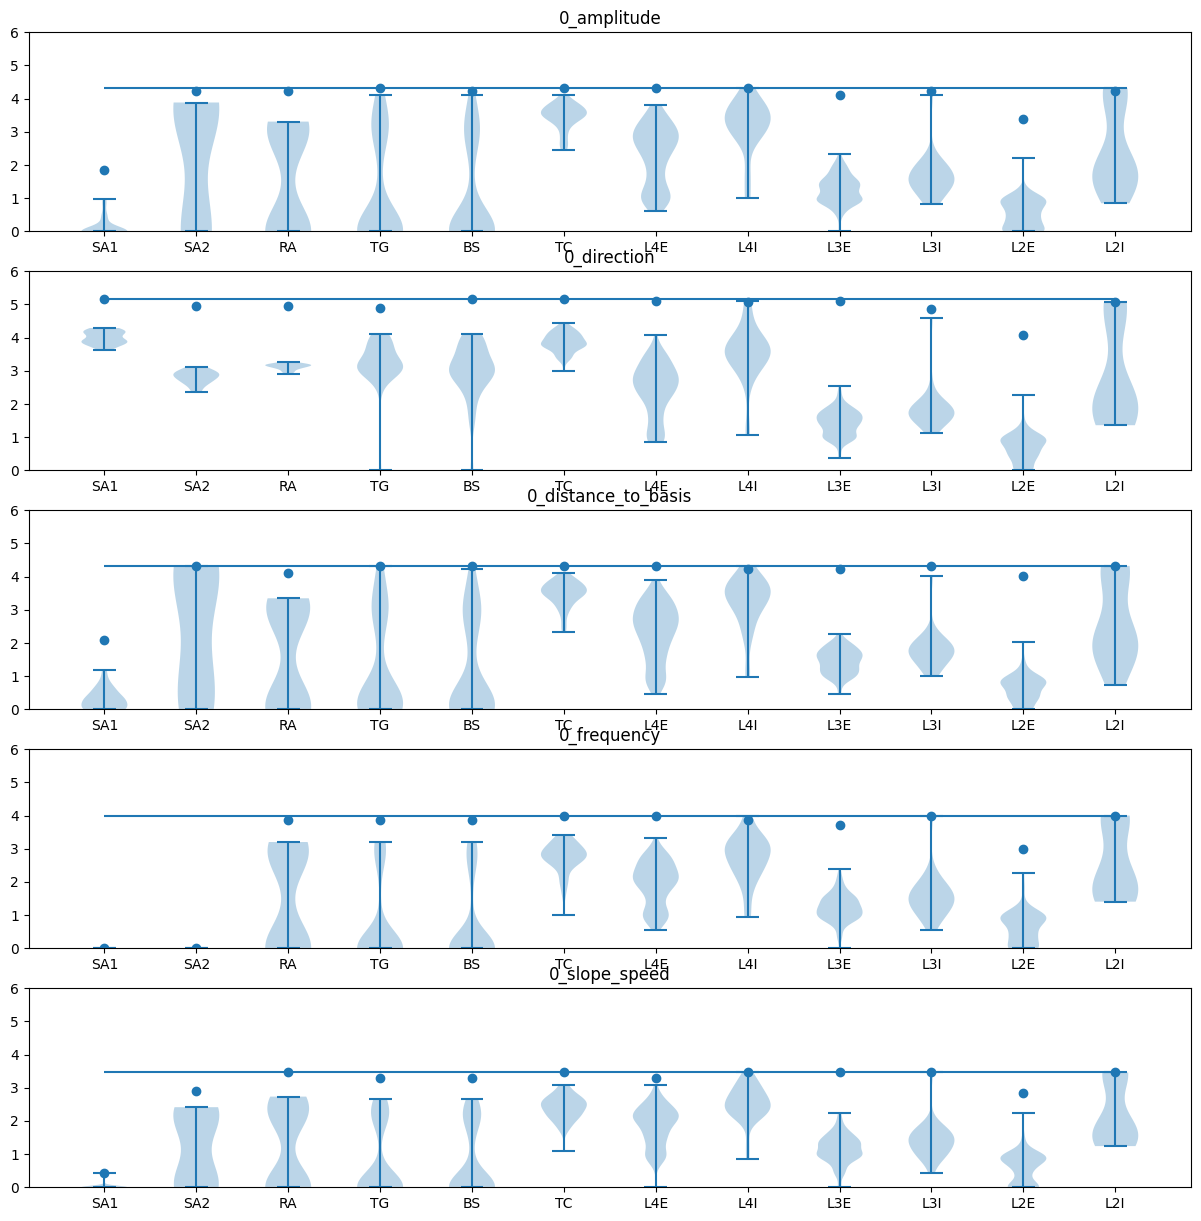

In [7]:
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_label = ['SA1', 'SA2', 'RA', 'TG', 'BS', 'TC', 'L4E', 'L4I', 'L3E', 'L3I', 'L2E', 'L2I']
Populations_sizes = [24, 10, 36, 70, 70, 70, 188, 33, 158, 28, 86, 15]
Stimulus = ['0_amplitude', '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']
fig, axs = plt.subplots(5, figsize=(15, 15))
for idx, stim in enumerate(Stimulus):
    best_neurons = []
    mi_per_pop = []
    mi_per_neuron_per_pop = []
    for j in range(len(Populations)):
        mi_per_neuron = []
        popsize = Populations_sizes[j]
        neural_act, stim_id = load_data(stim, '/' + Populations[j], '/spike_id')
        spike_per_neuron_per_stimulus = np.zeros((len(neural_act), popsize))
        for i in range(len(spike_per_neuron_per_stimulus)):
            spike_per_neuron_per_stimulus[i] = compute_nb_spike_per_neuron(neural_act[i], popsize)
        co_inf = np.zeros((popsize, popsize))
        for i in range(popsize):
            mi_per_neuron.append(mutual_info_score(spike_per_neuron_per_stimulus[:, i], stim_id)/np.log(2))
        full_pop_rate = mutual_info_score(np.sum(spike_per_neuron_per_stimulus, axis=1), stim_id)/np.log(2)
        mi_per_pop.append(full_pop_rate)
        #    for k in range(popsize):
        #        co_inf[i, k] = co_information(spike_per_neuron_per_stimulus[:, i], spike_per_neuron_per_stimulus[:, k], stim_id)
        #sns.heatmap(co_inf)
        #plt.show()
        mi_per_neuron_per_pop.append(mi_per_neuron)#np.asarray(mi_per_neuron)[np.asarray(mi_per_neuron) > 0])
        best_neurons.append(np.asarray(mi_per_neuron).argmax())
        #dist_nb_spike = make_dist(spike_per_neuron_per_stimulus.sum(axis=1))
        dist_stim = make_dist(np.asarray(stim_id, dtype=int))
        
        #plt.scatter(j, mutual_info_score(spike_per_neuron_per_stimulus.sum(axis=1), stim_id)/np.log(2))
    axs[idx].scatter(np.arange(1, 13), mi_per_pop)
    axs[idx].violinplot(mi_per_neuron_per_pop)    
    axs[idx].hlines(entropy(dist_stim, base=2), 1, 12)
    axs[idx].set_ylim(0, 6)
    axs[idx].set_title(stim)
    axs[idx].set_xticks(np.arange(1,13), Populations_label)
    plt.savefig('./Figures/MI/MI_rate_bis.svg')
    #plt.show()
    np.savetxt('./MI_best_neuron_per_stim/' + stim + '.csv', best_neurons, delimiter=',')